In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [4]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

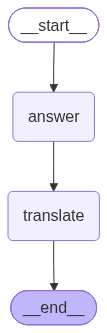

In [9]:
graph = parent_builder.compile()

graph

In [10]:
graph.invoke({'question': 'What is quantum physics'})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': 'What is quantum physics',
 'answer_eng': [{'type': 'text',
   'text': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the universe at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (like Newton\'s laws) explains how everyday objects like apples, cars, and planets move and interact, quantum physics explains how the fundamental building blocks of the universe work. At this microscopic level, the normal rules of physics no longer apply, and the universe behaves in very strange and counterintuitive ways.\n\nHere are the core concepts that define quantum physics:\n\n1. **Quantization:** Unlike energy or matter in our everyday world, which can flow smoothly in any amount, certain properties at the quantum level come in discrete, indivisible packets called **quanta**. Think of it like a staircase: you can stand on step 1 or step 2, but you cannot fl